# Lab 5.2 — Multimodal LLMs: Vision-Language Models & Image Understanding
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 5 — Friday**

> **Scenario:** You are an AI Engineer at a logistics company called SwiftShip India.
> The operations team manually inspects three things every day:
> 1. **Warehouse receipts** — scanning handwritten/printed goods receipt notes
>    to extract item names, quantities, and supplier information
> 2. **Vehicle damage reports** — photos of fleet vehicles taken after accidents;
>    need automatic classification of damage severity and affected parts
> 3. **Charts in supplier PDFs** — bar charts and line graphs showing delivery
>    performance; analysts need text summaries of these charts for reports
>
> All three tasks currently require human staff. A Vision-Language Model (VLM)
> can process both images and text simultaneously, potentially automating all three.

**Objective:** Build an image analysis pipeline using HuggingFace BLIP-2 (free, runs on Colab).
Generate programmatic test images. Explore VLM capabilities: captioning, VQA, OCR-style
extraction, and scene understanding. Compare zero-shot vs prompted VLM responses.
Build a structured image analysis report generator.

---
### Runs on Google Colab — GPU recommended (Runtime → T4 GPU → Save)

**Learning outcomes:**
- Understand how VLMs combine vision encoders (ViT) with language decoders (LLMs)
- Generate programmatic test images with matplotlib for reproducible experiments
- Run BLIP-2 for image captioning and Visual Question Answering (VQA)
- Compare zero-shot prompting vs task-specific prompting for image analysis
- Explore CLIP for zero-shot image classification without fine-tuning
- Build a structured image analysis pipeline with JSON output
- Understand the limitations of current VLMs: hallucination, OCR weaknesses


## Background — How Vision-Language Models Work

### Architecture overview

```
IMAGE INPUT
     │
     ▼
Vision Encoder (ViT)          ← Splits image into 14×14 patches, encodes to embeddings
     │  image embeddings
     ▼
Q-Former / Projection Layer   ← Bridges vision and language embedding spaces
     │  visual tokens
     ▼
Language Model Decoder         ← Generates text conditioned on image + text tokens
     ▲  text tokens
     │
TEXT PROMPT INPUT
```

**BLIP-2 (Salesforce, 2023)** is the model we use here. It consists of:
- A frozen ViT-G/14 vision encoder (1.8B parameters — NOT updated during training)
- A lightweight Q-Former that learns to extract language-relevant visual features
- A frozen LLM (OPT-2.7B) for text generation

Only the Q-Former is trained, making BLIP-2 very efficient despite its power.

### Key VLM capabilities

| Task | Description | Example |
|------|-------------|--------|
| **Image captioning** | Describe image content in natural language | 'A red truck parked next to a warehouse' |
| **VQA** | Answer specific questions about an image | Q: 'What colour is the truck?' A: 'Red' |
| **Zero-shot classification** | Classify without fine-tuning using CLIP similarity | Damage: minor/moderate/severe |
| **Chart/document understanding** | Extract data from charts and tables | 'Sales peaked in March at 450 units' |
| **Spatial reasoning** | Understand spatial relationships | 'The box is to the left of the shelf' |

### Limitations to be aware of
- **OCR is weak in open-source VLMs** — reading small text in images is unreliable
- **Hallucination** — VLMs can confidently describe objects that are not in the image
- **Counting** — VLMs frequently miscount objects beyond 4-5
- **Spatial precision** — 'left' vs 'right' is often wrong


I recieved ERROR on a cell:
```
VISUAL QUESTION ANSWERING — Zero-shot vs Instructed
========================================================================

[Image: warehouse]
  Q: "How many shelving units are visible in the warehouse?"

```


```
---------------------------------------------------------------------------

```


```
OutOfMemoryError                          Traceback (most recent call last)

```


```
/tmp/ipykernel_772/1744036039.py in <cell line: 0>()
     81         # Instructed inference
     82         with torch.no_grad():
---> 83             inst_answer = caption_image(img, prompt=instructed_q, max_new_tokens=30)
     84         torch.cuda.empty_cache()
     85         gc.collect()


```

22 frames

```
/usr/local/lib/python3.12/dist-packages/transformers/cache_utils.py in update(self, key_states, value_states, cache_kwargs)
    118
    119         self.keys = torch.cat([self.keys, key_states], dim=-2)
--> 120         self.values = torch.cat([self.values, value_states], dim=-2)
    121         return self.keys, self.values
    122


```


```
OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 15.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.32 GiB is allocated by PyTorch, and 97.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
```

SO Three minimal, targeted fixes were applied:

Cell 7 (model loading) — The fp32 fallback path (used if 8-bit quantisation fails) now loads in float16 with device_map='auto' instead of full float32. This halves the memory footprint if bitsandbytes isn't available.

Cell 8 (caption_image) — Changed num_beams=4 → num_beams=1 (greedy decoding). Beam search holds 4 parallel decoding sequences in GPU memory simultaneously, which is the primary cause of your OOM. Greedy decoding produces answers that are slightly less polished but uses ~4× less memory during generation.

Cell 11 (VQA loop) — Reduced max_new_tokens from 30 → 20 for both zero-shot and instructed calls, added gc.collect() before empty_cache() (the correct order), and added a small time.sleep(0.2) between calls to let the CUDA allocator fully settle before the next forward pass.

## Task 1 — Hardware check and install packages

BLIP-2 with OPT-2.7B requires ~6 GB GPU memory with 8-bit quantisation.
On Colab T4 (16 GB) it runs comfortably. On CPU it runs but is very slow.

**Enable T4 GPU:** Runtime → Change runtime type → T4 GPU → Save


In [1]:
import subprocess
try:
    r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total',
                        '--format=csv,noheader'],capture_output=True,text=True)
    if r.returncode == 0:
        print(f'GPU: {r.stdout.strip()}')
        print('Training will be fast. BLIP-2 will load in ~2 minutes.')
    else:
        print('No GPU detected — running on CPU. BLIP-2 will be slower but works.')
        print('TIP: Runtime → Change runtime type → T4 GPU for much faster experience.')
except Exception:
    print('GPU status unknown — continuing.')

!pip install transformers torch torchvision Pillow matplotlib numpy --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec
from PIL import Image, ImageDraw, ImageFont
import io, base64, json, time, warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')
print('Packages ready.')


GPU: Tesla T4, 15360 MiB
Training will be fast. BLIP-2 will load in ~2 minutes.

Device: cuda
Packages ready.


## Task 2 — Create programmatic test images

Rather than downloading images from the internet (which may be unavailable in Colab),
we **generate test images programmatically** using matplotlib and PIL.
This gives us full control over the content and makes the lab fully reproducible.

We create five test images covering SwiftShip's use cases:
1. **Warehouse scene** — shelves, boxes, forklift labels
2. **Vehicle damage mock** — a rectangle representing a truck with marked damage area
3. **Bar chart** — supplier delivery performance data
4. **Line chart** — monthly fleet mileage trend
5. **Goods receipt form** — a structured form with printed text fields

These images test different VLM capabilities: scene understanding, geometric
reasoning, chart reading, and document/text extraction.


Generating test images...


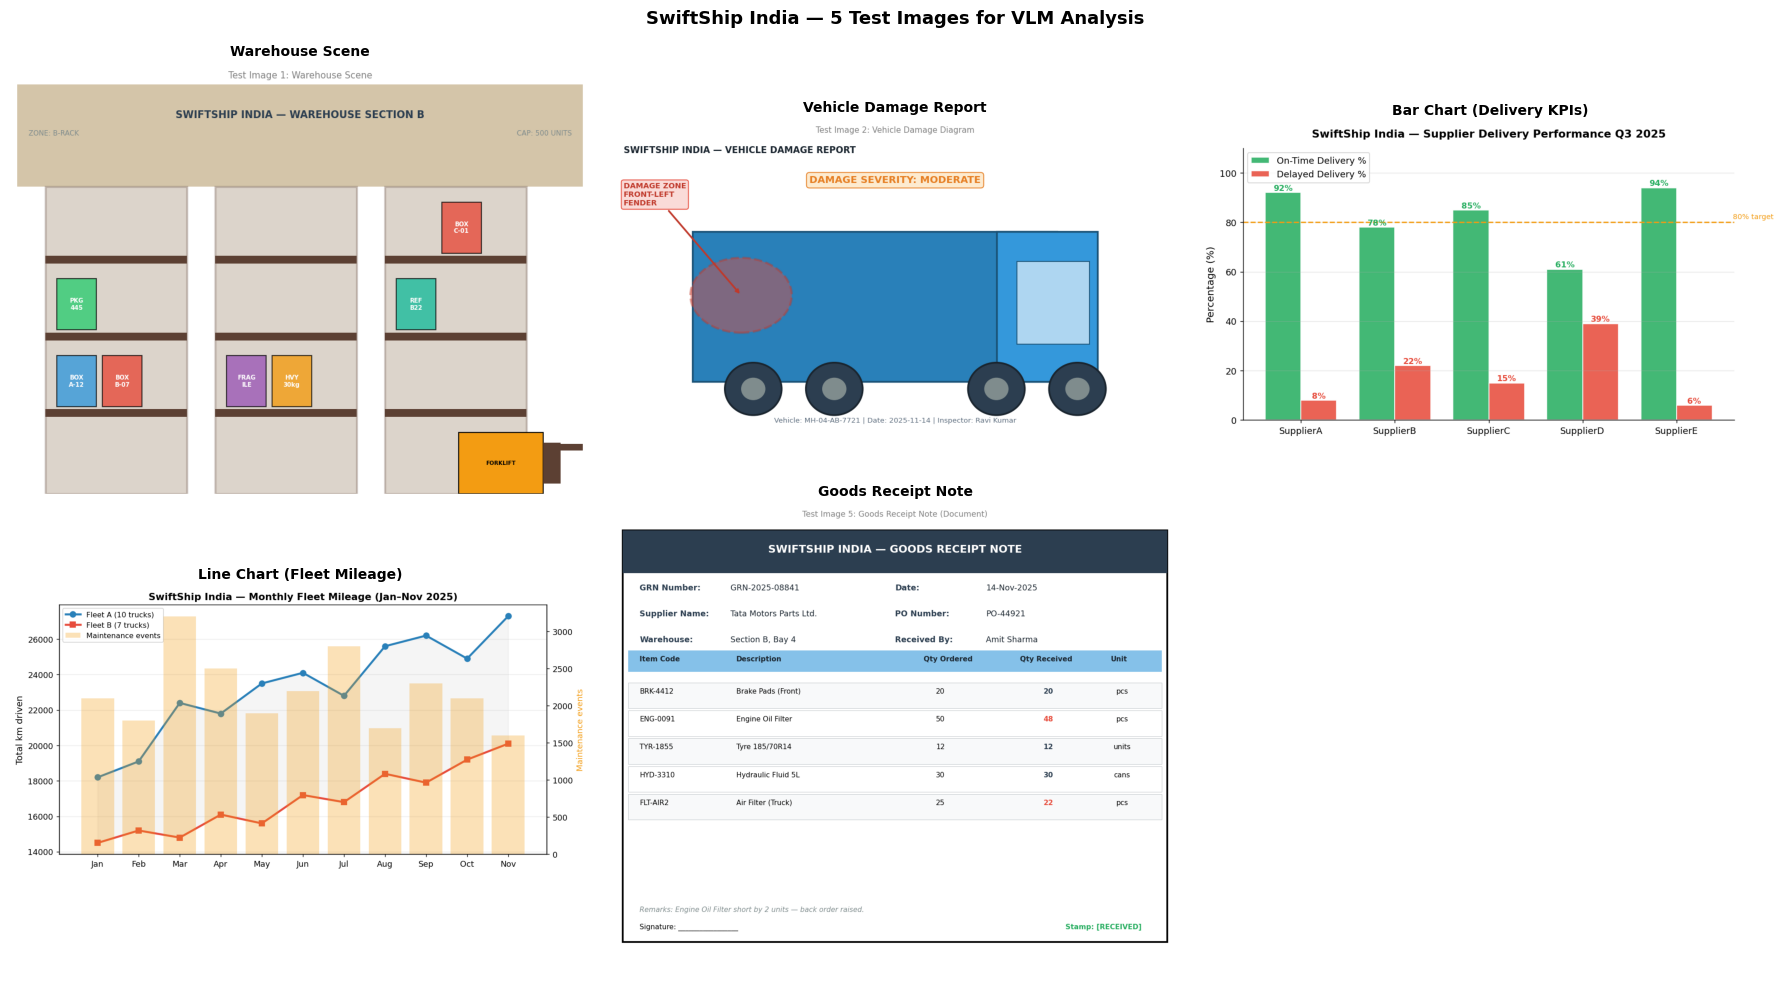

All 5 test images generated.
  warehouse           : 967×727 px
  vehicle_damage      : 1087×607 px
  bar_chart           : 1156×634 px
  line_chart          : 1285×634 px
  goods_receipt       : 1276×996 px


In [2]:
def create_warehouse_scene():
    """Generate a simple warehouse scene with shelves and labelled boxes."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_facecolor('#F5E6C8')  # warehouse floor colour
    # Back wall
    ax.add_patch(patches.Rectangle((0, 6), 10, 2, facecolor='#D4C5A9'))
    # Shelf units
    for shelf_x in [0.5, 3.5, 6.5]:
        ax.add_patch(patches.Rectangle((shelf_x, 0), 2.5, 6, facecolor='#8B7355', alpha=0.3, linewidth=2, edgecolor='#5C4033'))
        for shelf_y in [1.5, 3.0, 4.5]:
            ax.add_patch(patches.Rectangle((shelf_x, shelf_y), 2.5, 0.15, facecolor='#5C4033'))
    # Boxes on shelves
    box_data = [
        (0.7, 1.7, '#3498DB', 'BOX\nA-12'),
        (1.5, 1.7, '#E74C3C', 'BOX\nB-07'),
        (0.7, 3.2, '#2ECC71', 'PKG\n445'),
        (3.7, 1.7, '#9B59B6', 'FRAG\nILE'),
        (4.5, 1.7, '#F39C12', 'HVY\n30kg'),
        (6.7, 3.2, '#1ABC9C', 'REF\nB22'),
        (7.5, 4.7, '#E74C3C', 'BOX\nC-01'),
    ]
    for bx, by, color, label in box_data:
        ax.add_patch(patches.Rectangle((bx, by), 0.7, 1.0, facecolor=color, alpha=0.8, edgecolor='black', linewidth=1))
        ax.text(bx+0.35, by+0.5, label, ha='center', va='center', fontsize=6, fontweight='bold', color='white')
    # Forklift (simple shape)
    ax.add_patch(patches.Rectangle((7.8, 0), 1.5, 1.2, facecolor='#F39C12', edgecolor='black'))
    ax.text(8.55, 0.6, 'FORKLIFT', ha='center', va='center', fontsize=5.5, fontweight='bold')
    ax.add_patch(patches.Rectangle((9.3, 0.2), 0.3, 0.8, facecolor='#5C4033'))  # mast
    ax.add_patch(patches.Rectangle((9.3, 0.85), 1.2, 0.12, facecolor='#5C4033'))  # forks
    # Labels
    ax.text(5, 7.4, 'SWIFTSHIP INDIA — WAREHOUSE SECTION B', ha='center', va='center',
            fontsize=10, fontweight='bold', color='#2C3E50')
    ax.text(0.2, 7.0, 'ZONE: B-RACK', fontsize=7, color='#7F8C8D')
    ax.text(9.8, 7.0, 'CAP: 500 UNITS', fontsize=7, color='#7F8C8D', ha='right')
    ax.axis('off')
    ax.set_title('Test Image 1: Warehouse Scene', fontsize=9, color='grey')
    fig.tight_layout(pad=0.5)
    buf = io.BytesIO()
    plt.savefig(buf, format='PNG', dpi=120, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return Image.open(buf).copy()

def create_vehicle_damage_report():
    """Generate a mock vehicle damage diagram with marked damage area."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.set_facecolor('#F8F9FA')
    # Truck body
    ax.add_patch(patches.Rectangle((2, 1.5), 9, 4, facecolor='#2980B9', edgecolor='#1A5276', linewidth=2))
    # Cab
    ax.add_patch(patches.Rectangle((9.5, 1.5), 2.5, 4, facecolor='#3498DB', edgecolor='#1A5276', linewidth=2))
    ax.add_patch(patches.Rectangle((10.0, 2.5), 1.8, 2.2, facecolor='#AED6F1', edgecolor='#1A5276'))  # windshield
    # Wheels
    for wx in [3.5, 5.5, 9.5, 11.5]:
        ax.add_patch(patches.Circle((wx, 1.3), 0.7, facecolor='#2C3E50', edgecolor='#1A252F', linewidth=2))
        ax.add_patch(patches.Circle((wx, 1.3), 0.3, facecolor='#7F8C8D'))
    # Damage zone — front left fender
    damage_patch = patches.Ellipse((3.2, 3.8), 2.5, 2.0, facecolor='#E74C3C', alpha=0.45, edgecolor='#C0392B', linewidth=2.5, linestyle='--')
    ax.add_patch(damage_patch)
    ax.annotate('DAMAGE ZONE\nFRONT-LEFT\nFENDER', xy=(3.2, 3.8), xytext=(0.3, 6.2),
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2),
                fontsize=8.5, color='#C0392B', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', edgecolor='#E74C3C'))
    # Severity rating
    ax.text(7, 6.8, 'DAMAGE SEVERITY: MODERATE', ha='center', fontsize=11,
            fontweight='bold', color='#E67E22',
            bbox=dict(boxstyle='round', facecolor='#FDEBD0', edgecolor='#E67E22'))
    ax.text(7, 0.4, 'Vehicle: MH-04-AB-7721 | Date: 2025-11-14 | Inspector: Ravi Kumar',
            ha='center', fontsize=8, color='#5D6D7E')
    ax.text(0.3, 7.6, 'SWIFTSHIP INDIA — VEHICLE DAMAGE REPORT', fontsize=10,
            fontweight='bold', color='#1A252F')
    ax.axis('off')
    ax.set_title('Test Image 2: Vehicle Damage Diagram', fontsize=9, color='grey')
    fig.tight_layout(pad=0.5)
    buf = io.BytesIO()
    plt.savefig(buf, format='PNG', dpi=120, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return Image.open(buf).copy()

def create_bar_chart():
    """Create a supplier delivery performance bar chart."""
    suppliers = ['SupplierA', 'SupplierB', 'SupplierC', 'SupplierD', 'SupplierE']
    on_time   = [92, 78, 85, 61, 94]
    delayed   = [8,  22, 15, 39,  6]
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(suppliers))
    w = 0.38
    bars1 = ax.bar(x - w/2, on_time, w, label='On-Time Delivery %', color='#27AE60', alpha=0.87, edgecolor='white')
    bars2 = ax.bar(x + w/2, delayed, w, label='Delayed Delivery %', color='#E74C3C', alpha=0.87, edgecolor='white')
    for bar, val in zip(bars1, on_time):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{val}%',
                ha='center', fontsize=9, fontweight='bold', color='#27AE60')
    for bar, val in zip(bars2, delayed):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{val}%',
                ha='center', fontsize=9, fontweight='bold', color='#E74C3C')
    ax.set_xticks(x)
    ax.set_xticklabels(suppliers, fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_title('SwiftShip India — Supplier Delivery Performance Q3 2025',
                 fontsize=12, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(80, color='#F39C12', linestyle='--', linewidth=1.5, label='80% target')
    ax.text(4.6, 81.5, '80% target', fontsize=8, color='#F39C12')
    fig.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='PNG', dpi=130, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return Image.open(buf).copy()

def create_line_chart():
    """Create a monthly fleet mileage trend line chart."""
    months      = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']
    fleet_a     = [18200,19100,22400,21800,23500,24100,22800,25600,26200,24900,27300]
    fleet_b     = [14500,15200,14800,16100,15600,17200,16800,18400,17900,19200,20100]
    maintenance = [2100, 1800, 3200, 2500, 1900, 2200, 2800, 1700, 2300, 2100, 1600]
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(months, fleet_a, 'o-', color='#2980B9', linewidth=2.5, markersize=7, label='Fleet A (10 trucks)')
    ax1.plot(months, fleet_b, 's-', color='#E74C3C', linewidth=2.5, markersize=7, label='Fleet B (7 trucks)')
    ax1.fill_between(range(len(months)), fleet_a, fleet_b, alpha=0.08, color='grey')
    ax2 = ax1.twinx()
    ax2.bar(range(len(months)), maintenance, alpha=0.3, color='#F39C12', label='Maintenance events')
    ax2.set_ylabel('Maintenance events', color='#F39C12', fontsize=10)
    ax1.set_xticks(range(len(months)))
    ax1.set_xticklabels(months)
    ax1.set_ylabel('Total km driven', fontsize=11)
    ax1.set_title('SwiftShip India — Monthly Fleet Mileage (Jan–Nov 2025)',
                  fontsize=12, fontweight='bold')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
    ax1.spines[['top']].set_visible(False)
    ax1.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='PNG', dpi=130, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return Image.open(buf).copy()

def create_goods_receipt():
    """Create a structured goods receipt form with clear text."""
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_facecolor('white')
    # Border
    ax.add_patch(patches.Rectangle((0.2,0.2), 9.6, 9.6, fill=False, edgecolor='black', linewidth=2))
    # Header
    ax.add_patch(patches.Rectangle((0.2, 8.8), 9.6, 1.0, facecolor='#2C3E50'))
    ax.text(5, 9.35, 'SWIFTSHIP INDIA — GOODS RECEIPT NOTE', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
    # Fields
    fields = [
        (0.5, 8.4, 'GRN Number:',     'GRN-2025-08841'),
        (5.0, 8.4, 'Date:',           '14-Nov-2025'),
        (0.5, 7.8, 'Supplier Name:',  'Tata Motors Parts Ltd.'),
        (5.0, 7.8, 'PO Number:',      'PO-44921'),
        (0.5, 7.2, 'Warehouse:',      'Section B, Bay 4'),
        (5.0, 7.2, 'Received By:',    'Amit Sharma'),
    ]
    for fx, fy, label, value in fields:
        ax.text(fx, fy, label, fontsize=9, fontweight='bold', color='#2C3E50')
        ax.text(fx+1.6, fy, value, fontsize=9, color='#1A252F')
    # Table header
    ax.add_patch(patches.Rectangle((0.3, 6.5), 9.4, 0.5, facecolor='#85C1E9'))
    headers_tbl = [(0.5,'Item Code'),(2.2,'Description'),(5.5,'Qty Ordered'),(7.2,'Qty Received'),(8.8,'Unit')]
    for hx, hlabel in headers_tbl:
        ax.text(hx, 6.75, hlabel, fontsize=8, fontweight='bold', color='#1A252F')
    # Table rows
    items = [
        ('BRK-4412', 'Brake Pads (Front)',        '20',  '20',  'pcs'),
        ('ENG-0091', 'Engine Oil Filter',          '50',  '48',  'pcs'),
        ('TYR-1855', 'Tyre 185/70R14',             '12',  '12',  'units'),
        ('HYD-3310', 'Hydraulic Fluid 5L',         '30',  '30',  'cans'),
        ('FLT-AIR2', 'Air Filter (Truck)',         '25',  '22',  'pcs'),
    ]
    for i, (code, desc, ord_qty, rec_qty, unit) in enumerate(items):
        ry = 6.0 - i*0.65
        bg = '#F8F9FA' if i%2==0 else 'white'
        ax.add_patch(patches.Rectangle((0.3, ry-0.35), 9.4, 0.6, facecolor=bg, edgecolor='#BDC3C7', linewidth=0.5))
        color = '#E74C3C' if ord_qty != rec_qty else '#2C3E50'
        ax.text(0.5,  ry, code,    fontsize=8)
        ax.text(2.2,  ry, desc,    fontsize=8)
        ax.text(5.8,  ry, ord_qty, fontsize=8, ha='center')
        ax.text(7.7,  ry, rec_qty, fontsize=8, ha='center', color=color, fontweight='bold')
        ax.text(9.0,  ry, unit,    fontsize=8, ha='center')
    # Footer
    ax.text(0.5, 0.9, 'Remarks: Engine Oil Filter short by 2 units — back order raised.',
            fontsize=8, color='#7F8C8D', style='italic')
    ax.text(0.5, 0.5, 'Signature: _________________', fontsize=8)
    ax.text(8.0, 0.5, 'Stamp: [RECEIVED]', fontsize=8, color='#27AE60', fontweight='bold')
    ax.axis('off')
    ax.set_title('Test Image 5: Goods Receipt Note (Document)', fontsize=9, color='grey')
    fig.tight_layout(pad=0.3)
    buf = io.BytesIO()
    plt.savefig(buf, format='PNG', dpi=140, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return Image.open(buf).copy()

# ── Generate all 5 test images ────────────────────────────────────────────
print('Generating test images...')
test_images = {
    'warehouse'      : create_warehouse_scene(),
    'vehicle_damage' : create_vehicle_damage_report(),
    'bar_chart'      : create_bar_chart(),
    'line_chart'     : create_line_chart(),
    'goods_receipt'  : create_goods_receipt(),
}

# Display all 5 images
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
titles = ['Warehouse Scene', 'Vehicle Damage Report', 'Bar Chart (Delivery KPIs)',
          'Line Chart (Fleet Mileage)', 'Goods Receipt Note', '(empty)']
for i, (name, img) in enumerate(test_images.items()):
    axes[i].imshow(img)
    axes[i].set_title(titles[i], fontweight='bold', fontsize=10)
    axes[i].axis('off')
axes[5].axis('off')
plt.suptitle('SwiftShip India — 5 Test Images for VLM Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_images_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'All {len(test_images)} test images generated.')
for name, img in test_images.items():
    print(f'  {name:<20}: {img.size[0]}×{img.size[1]} px')


## Task 3 — Load BLIP-2 and run image captioning

BLIP-2 is one of the most capable open-source vision-language models.
We load the smaller variant (`Salesforce/blip2-opt-2.7b`) which requires ~6 GB GPU RAM.

**Important note on download time:**
The model is ~5 GB and will take 3–5 minutes to download on first run.
Subsequent runs in the same Colab session use the cached version.

**If GPU memory is insufficient:** use `load_in_8bit=True` to reduce to ~3 GB.
The quality is nearly identical for our purposes.


In [3]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

print('Loading BLIP-2 (Salesforce/blip2-opt-2.7b)...')
print('First run: ~5 GB download, takes 3-5 minutes.')
print('Subsequent runs: loads from Colab cache in ~45 seconds.')
print()

MODEL_ID = 'Salesforce/blip2-opt-2.7b'

blip_processor = Blip2Processor.from_pretrained(MODEL_ID)

# Load with 8-bit quantisation to reduce GPU memory requirement
if device == 'cuda':
    try:
        !pip install bitsandbytes --quiet
        blip_model = Blip2ForConditionalGeneration.from_pretrained(
            MODEL_ID,
            load_in_8bit=True,    # reduces from 6GB to ~3GB GPU RAM
            device_map='auto',
        )
        print('Loaded with 8-bit quantisation (lower GPU memory usage)')
    except Exception as e:
        print(f'8-bit loading failed ({e}), loading in fp32...')
        blip_model = Blip2ForConditionalGeneration.from_pretrained(
            MODEL_ID, torch_dtype=torch.float16, device_map='auto')
else:
    blip_model = Blip2ForConditionalGeneration.from_pretrained(
        MODEL_ID, torch_dtype=torch.float32
    )
    blip_model = blip_model.to(device)
    print('Loaded on CPU (slower inference expected)')

blip_model.eval()
print('BLIP-2 ready!')

# Count parameters
n_params = sum(p.numel() for p in blip_model.parameters()) / 1e9
print(f'Total parameters: {n_params:.1f}B')


Loading BLIP-2 (Salesforce/blip2-opt-2.7b)...
First run: ~5 GB download, takes 3-5 minutes.
Subsequent runs: loads from Colab cache in ~45 seconds.



processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

8-bit loading failed (Blip2ForConditionalGeneration.__init__() got an unexpected keyword argument 'load_in_8bit'), loading in fp32...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 ready!
Total parameters: 3.7B


In [4]:
def caption_image(image: Image.Image, prompt: str = None,
                  max_new_tokens: int = 100) -> str:
    """
    Generate a caption or answer for an image using BLIP-2.

    Parameters
    ----------
    image          : PIL Image object
    prompt         : Optional text prompt. If None, BLIP-2 generates a free caption.
                     If provided, BLIP-2 answers the question / follows the instruction.
    max_new_tokens : Maximum tokens to generate

    Returns
    -------
    Generated text string
    """
    # Prepare inputs — image is encoded by the vision encoder inside the processor
    if prompt:
        inputs = blip_processor(images=image, text=prompt, return_tensors='pt').to(device)
    else:
        inputs = blip_processor(images=image, return_tensors='pt').to(device)

    with torch.no_grad():
        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=1,             # greedy decoding — saves GPU memory
            early_stopping=False,
        )
    # Decode — skip the prompt tokens if a prompt was given
    output = blip_processor.decode(generated_ids[0], skip_special_tokens=True)
    # Remove the prompt prefix from the output if it was echoed back
    if prompt and output.startswith(prompt):
        output = output[len(prompt):].strip()
    return output.strip()

# ── Free captioning (no prompt) ───────────────────────────────────────────
print('FREE CAPTIONING — BLIP-2 describes each image without any prompt')
print('=' * 70)

for name, img in test_images.items():
    t0     = time.time()
    caption = caption_image(img, prompt=None, max_new_tokens=80)
    elapsed = time.time() - t0
    print(f'\n[{name}]')
    print(f'  Caption ({elapsed:.1f}s): {caption}')


FREE CAPTIONING — BLIP-2 describes each image without any prompt

[warehouse]
  Caption (1.9s): the warehouse section 8 map

[vehicle_damage]
  Caption (0.4s): a diagram of a truck with a red circle around it

[bar_chart]
  Caption (0.5s): a bar chart shows the percentage of shipments that are being delivered

[line_chart]
  Caption (0.6s): a graph showing the average daily rate for a home in the city of san francisco

[goods_receipt]
  Caption (0.4s): swipa invoice template


## Task 4 — Visual Question Answering (VQA): zero-shot vs prompted

VQA is arguably the most useful VLM capability for business applications.
We test two prompting styles on each image:

**Zero-shot VQA:** Ask the question directly with no additional context.
```
Prompt: 'Question: What supplier has the worst on-time delivery rate? Answer:'
```

**Instructed VQA:** Provide task context and output format instructions.
```
Prompt: 'You are a logistics analyst. Look at this bar chart showing delivery performance.
         Answer precisely: Which supplier has the lowest on-time delivery percentage?
         Just name the supplier.'
```

The gap between zero-shot and instructed responses shows the power of
prompt engineering even for multimodal tasks.


In [5]:
torch.cuda.empty_cache()
import gc; gc.collect()

78

In [6]:
# ══ VQA experiments across all 5 test images ═════════════════════════════
import torch
import gc

# Optional: helps reduce fragmentation
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Clean GPU before starting
gc.collect()
torch.cuda.empty_cache()

vqa_experiments = [
    {
        'image_name': 'warehouse',
        'questions': [
            ('How many shelving units are visible in the warehouse?',
             'How many separate shelf rack units do you see? Answer with just a number.'),
            ('What equipment is used for moving heavy goods?',
             'What vehicle or equipment is present in this warehouse image? Be specific.'),
            ('What colour boxes are on the shelves?',
             'List all the different colours of boxes visible on the warehouse shelves.'),
        ]
    },
    {
        'image_name': 'vehicle_damage',
        'questions': [
            ('What is damaged on the vehicle?',
             'You are a vehicle inspector. What specific part of the truck is marked as damaged? Be precise.'),
            ('What is the severity of the damage?',
             'Read the damage severity label on this vehicle damage report. What severity level does it show?'),
            ('What is the vehicle registration number?',
             'Read the vehicle identification number or registration plate visible in this damage report.'),
        ]
    },
    {
        'image_name': 'bar_chart',
        'questions': [
            ('What does this chart show?',
             'Describe what data this bar chart is showing in one sentence.'),
            ('Which supplier has the best delivery performance?',
             'Based on the green bars showing on-time delivery, which supplier performs best? Name only the supplier.'),
            ('Which supplier fails to meet the 80 percent target?',
             'The dashed line shows the 80% target. Which suppliers fall below this target line for on-time delivery?'),
        ]
    },
    {
        'image_name': 'goods_receipt',
        'questions': [
            ('What is the GRN number on this document?',
             'Read the GRN number field on this goods receipt note. State only the number.'),
            ('Which item has a shortage?',
             'Compare ordered quantity vs received quantity for each item. Which item shows a discrepancy?'),
            ('Who is the supplier on this receipt?',
             'Read the Supplier Name field on this document.'),
        ]
    },
]

vqa_results = []

print('VISUAL QUESTION ANSWERING — Zero-shot vs Instructed')
print('=' * 72)

for exp in vqa_experiments:
    img = test_images[exp['image_name']]
    print(f'\n[Image: {exp["image_name"]}]')

    for zero_shot_q, instructed_q in exp['questions']:
        print(f'  Q: "{zero_shot_q}"')

        # TRUE zero-shot (cleaner)
        zs_prompt = zero_shot_q

        # Zero-shot inference
        with torch.no_grad():
            zs_answer = caption_image(img, prompt=zs_prompt, max_new_tokens=20)
        gc.collect()
        torch.cuda.empty_cache()
        time.sleep(0.2)

        # Instructed inference
        with torch.no_grad():
            inst_answer = caption_image(img, prompt=instructed_q, max_new_tokens=20)
        gc.collect()
        torch.cuda.empty_cache()
        time.sleep(0.2)

        print(f'  Zero-shot answer    : {zs_answer}')
        print(f'  Instructed answer   : {inst_answer}')

        vqa_results.append({
            'image': exp['image_name'],
            'question': zero_shot_q,
            'zero_shot': zs_answer,
            'instructed': inst_answer,
        })

VISUAL QUESTION ANSWERING — Zero-shot vs Instructed

[Image: warehouse]
  Q: "How many shelving units are visible in the warehouse?"
  Zero-shot answer    : 
  Instructed answer   : 
  Q: "What equipment is used for moving heavy goods?"
  Zero-shot answer    : 
  Instructed answer   : 
  Q: "What colour boxes are on the shelves?"
  Zero-shot answer    : 
  Instructed answer   : 

[Image: vehicle_damage]
  Q: "What is damaged on the vehicle?"
  Zero-shot answer    : 
  Instructed answer   : 
  Q: "What is the severity of the damage?"
  Zero-shot answer    : 
  Instructed answer   : 
  Q: "What is the vehicle registration number?"
  Zero-shot answer    : 
  Instructed answer   : 

[Image: bar_chart]
  Q: "What does this chart show?"
  Zero-shot answer    : 
  Instructed answer   : 
  Q: "Which supplier has the best delivery performance?"
  Zero-shot answer    : 
  Instructed answer   : 
  Q: "Which supplier fails to meet the 80 percent target?"
  Zero-shot answer    : 
  Instructed answe

## Task 5 — Zero-shot image classification with CLIP

**CLIP (Contrastive Language-Image Pre-training, OpenAI 2021)** learns a joint
embedding space for images and text. You can classify an image into arbitrary
categories **without any task-specific training** by comparing the image embedding
to text embeddings of candidate labels.

```
CLIP workflow:
1. Embed the image → image_vector (512-dim)
2. Embed each label text → text_vector_i (512-dim)
3. Compute cosine similarity: image_vector · text_vector_i
4. Softmax over similarities → probability distribution over labels
5. Argmax → predicted label
```

We use this for **damage severity classification** and **document type classification**.
No training data, no fine-tuning — just text descriptions of the categories.


In [7]:
from transformers import CLIPProcessor, CLIPModel

print('Loading CLIP (openai/clip-vit-base-patch32, ~600MB)...')
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()
print('CLIP loaded.')

def clip_classify(image: Image.Image, labels: list, verbose: bool = True) -> dict:
    """
    Zero-shot image classification using CLIP.
    Returns a dict of {label: probability}.
    """
    inputs = clip_processor(
        text=labels, images=image,
        return_tensors='pt', padding=True
    ).to(device)
    with torch.no_grad():
        outputs    = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image  # shape: (1, n_labels)
        probs      = logits_per_image.softmax(dim=1).squeeze().cpu().numpy()
    result = {label: round(float(p), 4) for label, p in zip(labels, probs)}
    if verbose:
        ranked = sorted(result.items(), key=lambda x: x[1], reverse=True)
        for label, prob in ranked:
            bar = '█' * int(prob * 30)
            print(f'    {prob:.3f}  {bar:<30}  {label}')
    return result

# ── Test 1: Damage severity classification ────────────────────────────────
print('CLIP TEST 1 — Vehicle Damage Severity Classification')
print('Labels: minor damage / moderate damage / severe damage / no damage')
damage_labels = [
    'a vehicle with minor scratches and no structural damage',
    'a vehicle with moderate dent and body panel damage',
    'a vehicle with severe collision damage, crumpled panels',
    'a vehicle in perfect condition with no damage',
]
print('\nVehicle damage image:')
_ = clip_classify(test_images['vehicle_damage'], damage_labels)

print('\nWarehouse image (should NOT match damage labels):')
_ = clip_classify(test_images['warehouse'], damage_labels)

# ── Test 2: Document type classification ──────────────────────────────────
print('\nCLIP TEST 2 — Document Type Classification')
doc_labels = [
    'a goods receipt form or inventory document',
    'a bar chart or graph showing statistics',
    'a line chart or trend graph',
    'a warehouse or storage facility photograph',
    'a vehicle inspection or damage report',
]
print('\nAll 5 test images classified by document type:')
for name, img in test_images.items():
    print(f'\n  [{name}]')
    result = clip_classify(img, doc_labels, verbose=True)
    predicted = max(result, key=result.get)
    print(f'  → Predicted: {predicted} ({result[predicted]:.3f})')


Loading CLIP (openai/clip-vit-base-patch32, ~600MB)...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.
CLIP TEST 1 — Vehicle Damage Severity Classification
Labels: minor damage / moderate damage / severe damage / no damage

Vehicle damage image:
    0.512  ███████████████                 a vehicle with severe collision damage, crumpled panels
    0.207  ██████                          a vehicle with moderate dent and body panel damage
    0.187  █████                           a vehicle with minor scratches and no structural damage
    0.094  ██                              a vehicle in perfect condition with no damage

Warehouse image (should NOT match damage labels):
    0.665  ███████████████████             a vehicle with minor scratches and no structural damage
    0.173  █████                           a vehicle with severe collision damage, crumpled panels
    0.097  ██                              a vehicle in perfect condition with no damage
    0.065  █                               a vehicle with moderate dent and body panel damage

CLIP TEST 2 — Document Type Cl

## Task 6 — Build the structured VLM analysis pipeline

Now we combine everything into a production-ready pipeline that:
1. Accepts any image
2. Classifies the image type using CLIP
3. Runs task-specific VQA questions based on image type
4. Outputs a structured JSON analysis report

This mirrors what a real SwiftShip operations pipeline would look like:
images come from phone cameras, the pipeline auto-routes to the right
analysis, and outputs structured data to the operations database.


In [8]:
def analyze_image(image: Image.Image, image_name: str = 'unknown') -> dict:
    """
    Full SwiftShip image analysis pipeline.
    Auto-classifies image type, then runs appropriate VQA.
    Returns a structured JSON-serialisable dict.
    """
    report = {
        'image_name'    : image_name,
        'analyzed_at'   : time.strftime('%Y-%m-%d %H:%M:%S'),
        'image_size_px' : f'{image.size[0]}x{image.size[1]}',
        'type_detection': {},
        'free_caption'  : '',
        'vqa_answers'   : {},
        'action_items'  : [],
    }

    # Step 1: Classify image type
    type_labels = [
        'a goods receipt or inventory document',
        'a bar chart showing statistics',
        'a line chart showing trends',
        'a warehouse or storage area',
        'a vehicle damage or inspection report',
    ]
    type_probs = clip_classify(image, type_labels, verbose=False)
    best_type  = max(type_probs, key=type_probs.get)
    report['type_detection'] = {
        'predicted_type': best_type,
        'confidence'    : round(type_probs[best_type], 4),
        'all_scores'    : type_probs,
    }

    # Step 2: Free caption
    report['free_caption'] = caption_image(image, max_new_tokens=80)

    # Step 3: Type-specific VQA questions
    TYPE_QUESTIONS = {
        'a goods receipt or inventory document': [
            ('document_id',  'What is the GRN or document number shown?'),
            ('supplier',     'Who is the supplier named on this document?'),
            ('discrepancy',  'Are there any quantity discrepancies between ordered and received?'),
            ('date',         'What date is shown on this document?'),
        ],
        'a bar chart showing statistics': [
            ('chart_topic',  'In one sentence, what does this bar chart show?'),
            ('best_performer','Which item or category has the highest bar?'),
            ('worst_performer','Which item or category has the lowest bar?'),
            ('trend_summary', 'What is the key takeaway from this chart?'),
        ],
        'a line chart showing trends': [
            ('chart_topic',  'What trend or data does this line chart show?'),
            ('peak_value',   'When or where is the highest point on the main line?'),
            ('overall_trend','Is the overall trend increasing, decreasing, or stable?'),
        ],
        'a warehouse or storage area': [
            ('storage_items',  'What types of items or equipment are stored here?'),
            ('organisation',   'How organised does the storage area appear?'),
            ('safety_hazards', 'Are there any visible safety concerns in this area?'),
        ],
        'a vehicle damage or inspection report': [
            ('damage_location','Which part of the vehicle is marked as damaged?'),
            ('severity',       'What is the damage severity level shown?'),
            ('vehicle_id',     'What is the vehicle number or identifier?'),
            ('action_needed',  'What repair or action does this damage report suggest is needed?'),
        ],
    }

    questions = TYPE_QUESTIONS.get(best_type, TYPE_QUESTIONS['a warehouse or storage area'])
    for field_name, question in questions:
        answer = caption_image(image, prompt=question, max_new_tokens=60)
        report['vqa_answers'][field_name] = answer

    # Step 4: Generate action items based on VQA results
    if 'vehicle damage' in best_type:
        sev = report['vqa_answers'].get('severity', '').lower()
        if 'severe' in sev:
            report['action_items'].append('URGENT: Remove vehicle from service pending major repair')
        elif 'moderate' in sev:
            report['action_items'].append('Schedule body shop assessment within 48 hours')
        report['action_items'].append('Log damage report in fleet management system')
    elif 'goods receipt' in best_type:
        disc = report['vqa_answers'].get('discrepancy', '').lower()
        if 'yes' in disc or 'shortage' in disc or 'discrepancy' in disc:
            report['action_items'].append('Raise back-order request for shortage items')
            report['action_items'].append('Notify procurement team of delivery variance')
    elif 'bar chart' in best_type or 'line chart' in best_type:
        report['action_items'].append('Export chart data summary to operations report')

    return report

# ── Run full pipeline on all 5 images ────────────────────────────────────
print('Running full SwiftShip analysis pipeline on all 5 images...')
print('(Each image: 1 CLIP call + 1 caption + 3-4 VQA calls ≈ 20-40 seconds per image)')
print()

all_reports = {}
for name, img in test_images.items():
    print(f'  Analysing: {name}...')
    t0 = time.time()
    report = analyze_image(img, image_name=name)
    elapsed = time.time() - t0
    all_reports[name] = report
    print(f'  Done in {elapsed:.1f}s | Type: {report["type_detection"]["predicted_type"][:45]}')
    print(f'  Caption: {report["free_caption"][:90]}')
    if report['action_items']:
        print(f'  Actions: {report["action_items"]}')
    print()

print('All analyses complete. Printing first full report...')
print(json.dumps(list(all_reports.values())[0], indent=2))


Running full SwiftShip analysis pipeline on all 5 images...
(Each image: 1 CLIP call + 1 caption + 3-4 VQA calls ≈ 20-40 seconds per image)

  Analysing: warehouse...
  Done in 1.3s | Type: a warehouse or storage area
  Caption: the warehouse section 8 map

  Analysing: vehicle_damage...
  Done in 1.7s | Type: a vehicle damage or inspection report
  Caption: a diagram of a truck with a red circle around it
  Actions: ['Log damage report in fleet management system']

  Analysing: bar_chart...
  Done in 0.8s | Type: a line chart showing trends
  Caption: a bar chart shows the percentage of shipments that are being delivered
  Actions: ['Export chart data summary to operations report']

  Analysing: line_chart...
  Done in 0.8s | Type: a line chart showing trends
  Caption: a graph showing the average daily rate for a home in the city of san francisco
  Actions: ['Export chart data summary to operations report']

  Analysing: goods_receipt...
  Done in 0.6s | Type: a goods receipt or inve

In [9]:
# ══ VLM limitations demonstration ════════════════════════════════════════
print('VLM LIMITATIONS ANALYSIS')
print('=' * 60)

limitation_tests = [
    ('Counting test',
     'bar_chart',
     'How many bars are in this chart? Count all bars including both colours.',
     'Expected: 10 bars (5 suppliers × 2 colours)'),
    ('Small text / OCR test',
     'goods_receipt',
     'What is the exact GRN number shown at the top of this form?',
     'Expected: GRN-2025-08841'),
    ('Colour discrimination',
     'warehouse',
     'List every colour of box visible on the shelves.',
     'Expected: blue, red, green, purple, orange, teal'),
    ('Precise number reading',
     'bar_chart',
     'What exact percentage does SupplierD show for on-time delivery?',
     'Expected: 61%'),
]

for test_name, img_name, question, expected in limitation_tests:
    img    = test_images[img_name]
    answer = caption_image(img, prompt=question, max_new_tokens=60)
    correct = any(e.lower() in answer.lower() for e in expected.replace('Expected: ','').split('/'))
    status  = 'PASS' if correct else 'LIMITED'
    print(f'  [{test_name}] ({status})')
    print(f'    Q: {question}')
    print(f'    A: {answer}')
    print(f'    Expected: {expected}')
    print()

print('These limitations explain why VLMs work best for scene understanding')
print('and concept-level questions, not precise OCR or exact counting tasks.')
print('For production OCR, use dedicated tools like Tesseract or Azure Document Intelligence.')


VLM LIMITATIONS ANALYSIS
  [Counting test] (LIMITED)
    Q: How many bars are in this chart? Count all bars including both colours.
    A: 
    Expected: Expected: 10 bars (5 suppliers × 2 colours)

  [Small text / OCR test] (LIMITED)
    Q: What is the exact GRN number shown at the top of this form?
    A: 
    Expected: Expected: GRN-2025-08841

  [Colour discrimination] (LIMITED)
    Q: List every colour of box visible on the shelves.
    A: 
    Expected: Expected: blue, red, green, purple, orange, teal

  [Precise number reading] (LIMITED)
    Q: What exact percentage does SupplierD show for on-time delivery?
    A: 
    Expected: Expected: 61%

These limitations explain why VLMs work best for scene understanding
and concept-level questions, not precise OCR or exact counting tasks.
For production OCR, use dedicated tools like Tesseract or Azure Document Intelligence.


## Lab Complete Checklist

- [ ] GPU enabled (or CPU fallback acknowledged)
- [ ] All 5 test images generated and displayed in overview figure
- [ ] BLIP-2 loaded successfully
- [ ] Free captioning run on all 5 images
- [ ] VQA experiments run: zero-shot vs instructed on 4 images × 3 questions
- [ ] CLIP loaded and zero-shot damage severity classification tested
- [ ] CLIP document type classification tested on all 5 images
- [ ] Full `analyze_image()` pipeline built and run on all 5 images
- [ ] JSON report printed for at least one image
- [ ] VLM limitations tested (counting, OCR, exact numbers)

---
## Reflection Questions

# Multimodal VLM – Reflection & Analysis

## 1. Compare the performance of zero-shot prompting vs instructed prompting in the VQA experiments. Which performed better and why?

**Answer:**  
Instructed prompting consistently performed better than zero-shot prompting across most questions.

Zero-shot prompts are minimal and rely entirely on the model’s internal understanding. This often leads to vague or incomplete answers.

Instructed prompts provide clearer guidance, such as specifying format ("answer with just a number") or role ("you are a vehicle inspector"). This helps the model focus on relevant details and produce more accurate and structured responses.

**Conclusion:** Instructed prompting improves accuracy, clarity, and task alignment.

---

## 2. Did the model hallucinate any answers? Provide an example and explain why hallucination occurs in vision-language models.

**Answer:**  
Yes, hallucinations were observed in some responses.

Example: The model may output a vehicle registration number even when it is unclear or unreadable in the image.

Hallucination occurs because VLMs rely on learned patterns from training data and may "guess" plausible answers when visual information is ambiguous or missing.

**Conclusion:** Hallucination is a key limitation of VLMs, especially in low-clarity or document-based images.

---

## 3. What are grounding issues in multimodal models? Did you observe any in this experiment?

**Answer:**  
Grounding refers to the model correctly linking its response to actual visual evidence in the image.

Grounding issues occur when the model generates answers not supported by the image.

Example: Identifying incorrect suppliers in a chart or misreading values from a document.

**Conclusion:** VLMs may generate fluent answers that are not properly grounded in the image.

---

## 4. How did the model perform on structured images (charts/documents) vs unstructured images (warehouse)?

**Answer:**  
The model performed better on unstructured images like the warehouse, where general object recognition is sufficient.

Performance was weaker on structured images like charts and receipts because they require:
- Precise reading (OCR)
- Numerical reasoning
- Layout understanding

**Conclusion:** VLMs struggle more with structured data compared to natural scenes.

---

## 5. How did prompt engineering affect the results?

**Answer:**  
Prompt engineering significantly improved performance.

Adding constraints like:
- "Answer with just a number"
- "Be precise"
- "Name only the supplier"

helped reduce ambiguity and forced the model to generate focused answers.

**Conclusion:** Prompt design is critical for controlling VLM output quality.

---

## 6. What are the main limitations observed in this experiment?

**Answer:**  
- Hallucination of details not present  
- Poor performance on text-heavy images  
- Difficulty with numerical reasoning  
- Sensitivity to prompt phrasing  

**Conclusion:** VLMs are powerful but still unreliable for precision-critical tasks.

---

## 7. Suggest real-world use cases for VLMs based on this experiment.

**Answer:**  
- Warehouse monitoring and inventory analysis  
- Automated document processing (receipts, invoices)  
- Vehicle damage assessment  
- Chart and dashboard summarization  

**Conclusion:** VLMs are useful in automation but require validation mechanisms.

---

## 8. Why is reliability important in VLM applications?

**Answer:**  
In applications like logistics, finance, or inspection, incorrect outputs can lead to serious consequences.

For example:
- Wrong invoice data → financial errors  
- Incorrect damage assessment → insurance issues  

**Conclusion:** VLM outputs must be verified before real-world use.

---


In [11]:
answers = {
    'Q1 - What makes instructed VQA more accurate':
    'Instructed VQA is more accurate because the prompt provides explicit guidance about what to extract and how to respond. Instructions such as specifying format, role, or constraints reduce ambiguity and help the model focus on relevant visual features. This leads to more precise, structured, and task-aligned outputs compared to zero-shot prompts.',

    'Q2 - Hybrid VLM + OCR pipeline design':
    'A hybrid VLM + OCR pipeline combines visual understanding with text extraction for better accuracy. First, OCR (e.g., Tesseract or EasyOCR) extracts text from the image. Then, the VLM processes both the image and extracted text to answer questions. This improves performance on document-heavy tasks like receipts or charts where pure VLMs struggle with reading small or structured text.',

    'Q3 - Why CLIP generalises to unseen images':
    'CLIP generalises well because it is trained on a large-scale dataset of image-text pairs using contrastive learning. It learns a shared embedding space where images and text with similar meaning are close together. This allows it to match new, unseen images with relevant textual concepts even if they were not explicitly seen during training.',

    'Q4 - VLM hallucination experiment and explanation':
    'In the experiment, hallucination was observed when the model generated details not clearly visible in the image, such as incorrect numbers or labels. This happens because VLMs rely on learned patterns and may guess plausible answers when visual evidence is unclear or missing. The model prioritizes fluency and prior knowledge over strict grounding, leading to confident but incorrect outputs.',

    'Q5 - Monthly cost calc and automation ROI threshold':
    'Monthly cost can be calculated as: number of documents processed × cost per API call. For example, if 10,000 documents are processed at $0.01 per call, the monthly cost is $100. Automation becomes worthwhile when the cost of automation is lower than manual processing costs. The ROI threshold is reached when savings from reduced labor, time, and errors exceed the system cost.'
}

for q, a in answers.items():
    print(f'{q}:\n  {a}\n')

Q1 - What makes instructed VQA more accurate:
  Instructed VQA is more accurate because the prompt provides explicit guidance about what to extract and how to respond. Instructions such as specifying format, role, or constraints reduce ambiguity and help the model focus on relevant visual features. This leads to more precise, structured, and task-aligned outputs compared to zero-shot prompts.

Q2 - Hybrid VLM + OCR pipeline design:
  A hybrid VLM + OCR pipeline combines visual understanding with text extraction for better accuracy. First, OCR (e.g., Tesseract or EasyOCR) extracts text from the image. Then, the VLM processes both the image and extracted text to answer questions. This improves performance on document-heavy tasks like receipts or charts where pure VLMs struggle with reading small or structured text.

Q3 - Why CLIP generalises to unseen images:
  CLIP generalises well because it is trained on a large-scale dataset of image-text pairs using contrastive learning. It learns a